In [ ]:
# # Cats vs Dogs Image Classification using CNN

# ## What are we going to do?

# - Load the Cats vs Dogs dataset
# - Explore the dataset
# - Display sample images
# - Preprocess images
# - Build a Convolutional Neural Network (CNN)
# - Train the model
# - Evaluate the model
# - Predict new images
# - Save the trained model

# ## Real World Applications

# - Pet Recognition
# - Animal Detection
# - CCTV Monitoring
# - Wildlife Monitoring
# - Smart Camera Systems

Import Required Libraries

In [1]:
import tensorflow as tf

import matplotlib.pyplot as plt

import numpy as np

import pathlib

Define Dataset Paths

In [2]:
train_path = pathlib.Path("../dataset/training_set")

test_path = pathlib.Path("../dataset/test_set")

Load Training Dataset

In [3]:
train_dataset = tf.keras.utils.image_dataset_from_directory(

    train_path,

    image_size=(150, 150),

    batch_size=32,

    shuffle=True

)

Found 8005 files belonging to 2 classes.


Load Test Dataset

In [4]:
test_dataset = tf.keras.utils.image_dataset_from_directory(

    test_path,

    image_size=(150, 150),

    batch_size=32,

    shuffle=False

)

Found 2023 files belonging to 2 classes.


Check Class Names

In [5]:
class_names = train_dataset.class_names

print(class_names)

['cats', 'dogs']


Display One Batch Shape

In [6]:
for images, labels in train_dataset.take(1):

    print("Images Shape :", images.shape)

    print("Labels Shape :", labels.shape)

Images Shape : (32, 150, 150, 3)
Labels Shape : (32,)


Display Sample Images

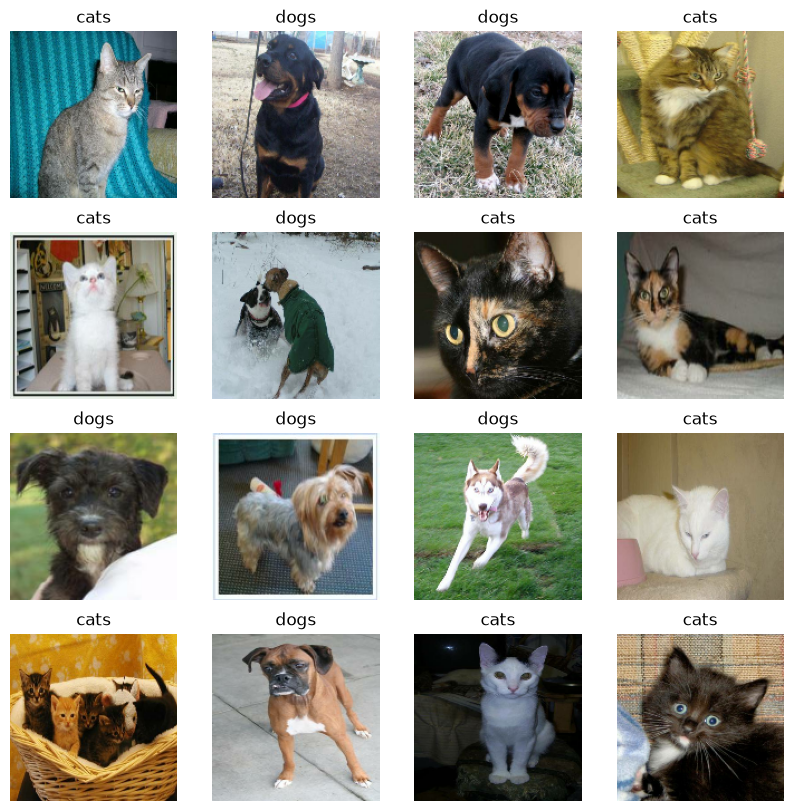

In [16]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(16):

        plt.subplot(4,4,i+1)

        plt.imshow(

            images[i].numpy().astype("uint8")

        )

        plt.title(

            class_names[labels[i]]

        )

        plt.axis("off")

plt.show()

Check Pixel Value Range

In [17]:
for images, labels in train_dataset.take(1):

    print("Minimum Pixel Value :", tf.reduce_min(images).numpy())

    print("Maximum Pixel Value :", tf.reduce_max(images).numpy())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 255.0


Create a Normalization Layer

In [18]:
normalization_layer = tf.keras.layers.Rescaling(

    1./255

)

Apply Normalization

In [19]:
train_dataset = train_dataset.map(

    lambda images, labels: (

        normalization_layer(images),

        labels

    )

)

test_dataset = test_dataset.map(

    lambda images, labels: (

        normalization_layer(images),

        labels

    )

)

Verify Normalization

In [20]:
for images, labels in train_dataset.take(1):

    print("Minimum Pixel Value :", tf.reduce_min(images).numpy())

    print("Maximum Pixel Value :", tf.reduce_max(images).numpy())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


Optimize the Data Pipeline

In [21]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(

    buffer_size=AUTOTUNE

)

test_dataset = test_dataset.cache().prefetch(

    buffer_size=AUTOTUNE

)

CNN ka Complete Flow

In [22]:
# Cat Image
#         ↓
# Convolution
# (Features Find)
#         ↓
# ReLU
# (Remove Negative Values)
#         ↓
# Pooling
# (Keep Important Features
#         ↓
# Flatten
# (Convert into 1D)
#         ↓
# Dense Layer
# (Classification)
#         ↓
# Softmax / Sigmoid
# ↓
# Cat / Dog

Build CNN Model

In [24]:
model = tf.keras.Sequential(

    [

        tf.keras.layers.Conv2D(

            filters=32,

            kernel_size=(3,3),

            activation="relu",

            input_shape=(150,150,3)

        ),

        tf.keras.layers.MaxPooling2D(

            pool_size=(2,2)

        ),

        tf.keras.layers.Conv2D(

            filters=64,

            kernel_size=(3,3),

            activation="relu"

        ),

        tf.keras.layers.MaxPooling2D(

            pool_size=(2,2)

        ),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(

            128,

            activation="relu"

        ),

        tf.keras.layers.Dense(

            1,

            activation="sigmoid"

        )

    ]

)

In [25]:
# # Understanding the CNN Architecture

# Before training the model, let's understand:

# - How many layers are there?
# - How many parameters does the model have?
# - How does the image size change after each layer?

# Understanding the architecture is as important as building the model.

Display Model Summary

In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,636,481 (40.57 MB)

 Trainable params: 10,636,481 (40.57 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# # Compile and Train the CNN Model

# Before training the model, we need to tell it:

# - Which optimizer to use?
# - Which loss function to use?
# - Which metric to measure?

# After that, the CNN starts learning from the training images.

Compile the CNN Model

In [29]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

Early Stopping

In [32]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

Train the CNN

In [34]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs = 20,
    callbacks = [early_stopping]
)

Epoch 1/20


e:\AI Learning\AI_ML\python\API\FastAPI_Professional\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


251/251 ━━━━━━━━━━━━━━━━━━━━ 57s 219ms/step - accuracy: 0.6195 - loss: 0.6665 - val_accuracy: 0.6688 - val_loss: 0.6036
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 42s 169ms/step - accuracy: 0.7348 - loss: 0.5242 - val_accuracy: 0.7069 - val_loss: 0.5747
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 43s 171ms/step - accuracy: 0.8262 - loss: 0.3711 - val_accuracy: 0.7024 - val_loss: 0.6890
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 40s 161ms/step - accuracy: 0.9004 - loss: 0.2435 - val_accuracy: 0.6891 - val_loss: 0.8103
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 39s 153ms/step - accuracy: 0.9233 - loss: 0.1912 - val_accuracy: 0.6911 - val_loss: 0.8934


Check Training History

In [35]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [36]:
# # Visualizing the Training Process

# After training, we visualize:

# - Training Accuracy
# - Validation Accuracy
# - Training Loss
# - Validation Loss

# These graphs help us understand how well the CNN has learned.

Plot Accuracy Graph

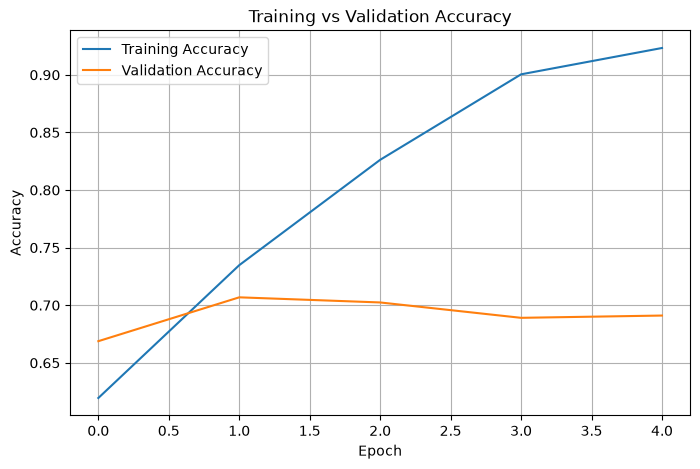

In [37]:
plt.figure(figsize=(8,5))

plt.plot(

    history.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    history.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

Plot Loss Graph

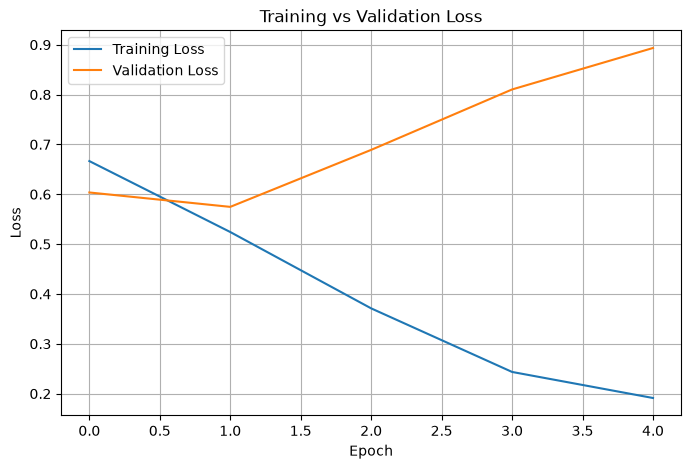

In [38]:
plt.figure(figsize=(8,5))

plt.plot(

    history.history["loss"],

    label="Training Loss"

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [39]:
# # Model Evaluation

# After training the CNN, we need to check:

# - How well does it perform on unseen images?
# - What is the final accuracy?
# - What is the final loss?

# Evaluation tells us how good our trained model is.

Evaluate the CNN Model

In [42]:
test_loss, test_accuracy = model.evaluate(

    test_dataset

)

print(f"Test Loss     : {test_loss:.4f}")

print(f"Test Accuracy : {test_accuracy:.4f}")

64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7069 - loss: 0.5747
Test Loss     : 0.5747
Test Accuracy : 0.7069


In [47]:
# # Predict Multiple Test Images

# Now we will test our trained CNN on multiple unseen images.

# Instead of predicting only one image, we will:

# - Select random images from the test dataset.
# - Predict each image.
# - Compare Actual vs Predicted labels.
# - Display prediction confidence.
# - Save the prediction results.

Import Required Libraries

In [48]:
import os
import random
import pandas as pd
from tensorflow.keras.preprocessing import image

Load One Test Image

In [46]:
image_path = "../dataset/test_set/cats/cat.4001.jpg"
img = image.load_img(

    image_path,

    target_size=(150,150)

)

Select 10 Random Test Images

In [49]:
test_cat_path = "../dataset/test_set/cats"

test_dog_path = "../dataset/test_set/dogs"

cat_images = [

    os.path.join(test_cat_path, img)

    for img in os.listdir(test_cat_path)

]

dog_images = [

    os.path.join(test_dog_path, img)

    for img in os.listdir(test_dog_path)

]

all_images = cat_images + dog_images

random_images = random.sample(

    all_images,

    10

)

In [51]:
# Predict Random Test Images

# Now the CNN will predict 10 random images from the test dataset.

Result and Save Prediction Image

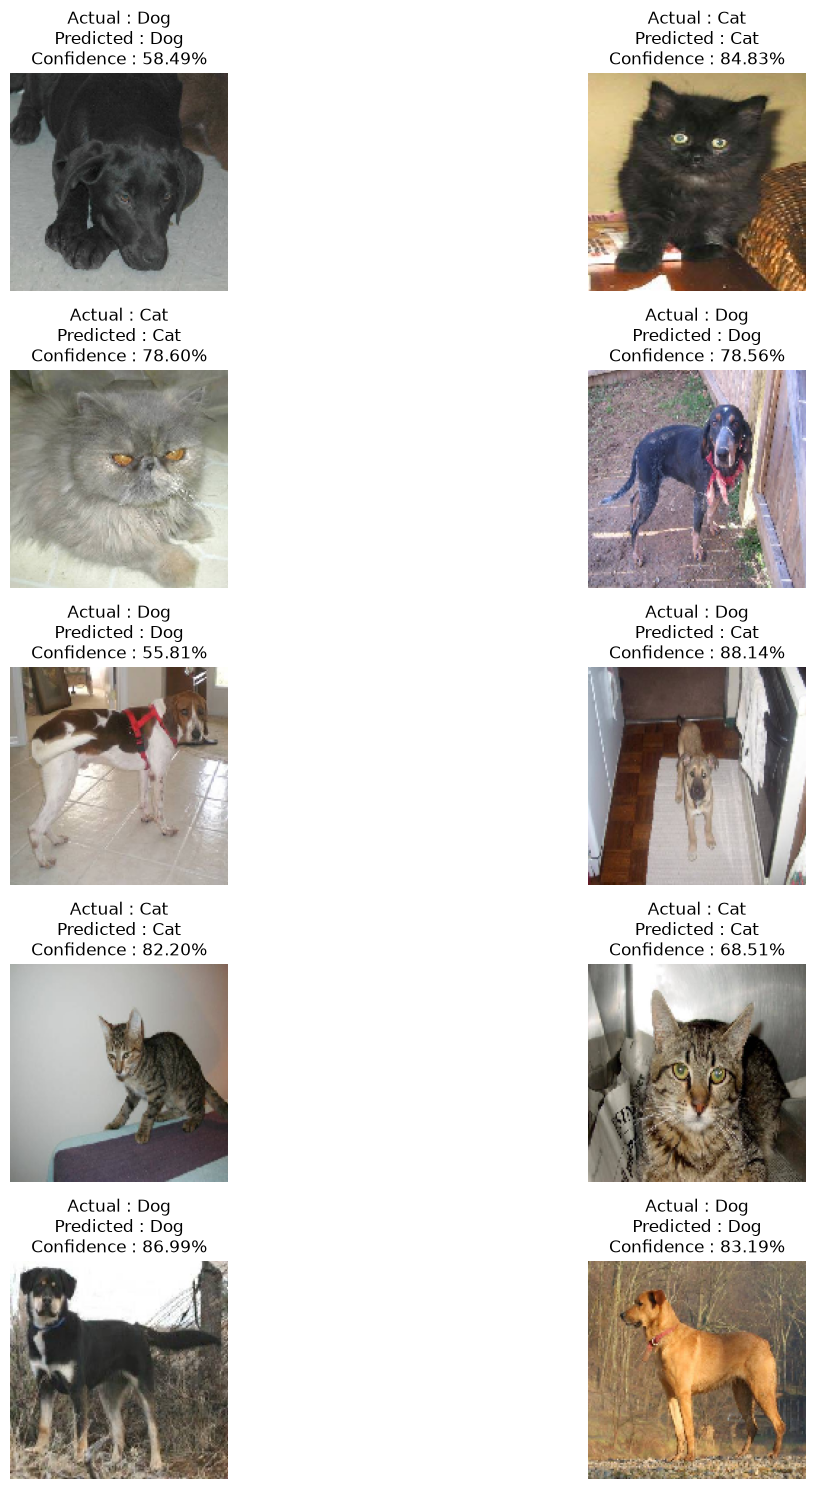

In [53]:
results = []

plt.figure(figsize=(15,15))

for i, image_path in enumerate(random_images):

    img = image.load_img(

        image_path,

        target_size=(150,150)

    )

    img_array = image.img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(

        img_array,

        axis=0

    )

    prediction = model.predict(

        img_array,

        verbose=0

    )

    probability = prediction[0][0]

    if probability > 0.5:

        predicted_label = "Dog"

        confidence = probability * 100

    else:

        predicted_label = "Cat"

        confidence = (1 - probability) * 100

    actual_label = (

        "Dog"

        if "dogs" in image_path

        else "Cat"

    )

    image_name = os.path.basename(image_path)

    results.append({

        "Image Name": image_name,

        "Actual": actual_label,

        "Predicted": predicted_label,

        "Confidence (%)": round(confidence,2)

    })

    plt.subplot(5,2,i+1)

    plt.imshow(img)

    plt.title(

        f"Actual : {actual_label}\n"

        f"Predicted : {predicted_label}\n"

        f"Confidence : {confidence:.2f}%"

    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(

    "../outputs/prediction_results.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

Save Prediction Report

In [54]:
prediction_df = pd.DataFrame(

    results

)

prediction_df.to_csv(

    "../outputs/prediction_results.csv",

    index=False

)

prediction_df.head()

,Image Name,Actual,Predicted,Confidence (%)
0,dog.4943.jpg,Dog,Dog,58.490002
1,cat.4830.jpg,Cat,Cat,84.830002
2,cat.4954.jpg,Cat,Cat,78.599998
3,dog.4578.jpg,Dog,Dog,78.559998
4,dog.4107.jpg,Dog,Dog,55.810001


In [55]:
# # Save the Trained Model

# Save the trained CNN model so that it can be reused later without retraining.

**Save the Trained Model**

In [56]:
model.save(

    "../saved_model/cats_vs_dogs_cnn.keras"

)

print("Model Saved Successfully!")

Model Saved Successfully!
